# 104 - Style Transfer with AlexNet

**Section:** Style Transfer | **Prereqs:** `Style Transfer/Neural_Style_Transfer.ipynb` | **Next:** end of course

The same algorithm on a much smaller network. AlexNet has 5 convolutional layers
against VGG-19's 16, so this runs far faster - and looks different, which is the
point of the comparison.

**Three deliberate changes from the VGG notebook**

1. **The target starts as a copy of the content image**, not noise. It converges
   faster and preserves the content much more strongly - the usual choice in
   practice, and the reason the result here looks less abstract.
2. **Static feature maps are computed once**, outside the loop, under
   `torch.no_grad()`. The content and style images never change, so recomputing
   their features every iteration is pure waste. Roughly a 3x speedup.
3. **A higher `style_scaling` (2e5)**, because AlexNet's Gram matrices are on a
   different scale. Every hyperparameter here is network-specific - none of them
   transfer between architectures.

**What you learn from the comparison.** AlexNet's 5 layers give coarser style: it
captures colour and broad texture but not the fine brushwork VGG picks up. Depth
buys the network a richer vocabulary of visual features - which is the same
argument as `More on Data/DepthVsBreadth.ipynb`, arriving here as a visible
difference in the output rather than a number.

**Note `content_layers = ['ConvLayer_0']`** - the very first layer, which is
almost raw edges. The inline comment says deeper layers represent content better,
and that is right; using layer 0 pins the target close to the original pixels.
Try `ConvLayer_2` or `ConvLayer_3` for a more interpretive result.

In [568]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as T

import imageio as iio

In [569]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

In [570]:
# AlexNet with ImageNet weights - 5 convolutional layers against VGG-19's 16.
# Far faster, and coarser features.
# Import model and freeze weights

alex_net = torchvision.models.alexnet(weights=torchvision.models.AlexNet_Weights.DEFAULT)
alex_net = alex_net.to(device) # Move the model to the same device as the inputs
alex_net = alex_net.eval()
alex_net

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [571]:
# Freeze the convolutional stack. Only .features is used, so the classifier is
# irrelevant here.
# Freezing Layers

for params in alex_net.features.parameters():
  params.requires_grad_(False)


In [572]:
for params in alex_net.features.parameters():
  print(params.requires_grad)


False
False
False
False
False
False
False
False
False
False


In [573]:
# The target starts as a COPY OF THE CONTENT IMAGE, not noise.
# Faster to converge and it preserves content far more strongly - the usual
# practical choice. The commented-out line is the noise start used in the VGG
# notebook, and the difference in output is worth seeing.
# Importing images.

content = iio.v3.imread('/content/mathew-schwartz-onOdABjwC0M-unsplash.jpg')  # uint8, range [0, 255]
style = iio.v3.imread('/content/alex-perez-ioJBsYQ-pPM-unsplash.jpg')

# target = np.random.randint(low=0, high=225, size=content.shape,dtype=np.uint8)
target = content.copy()

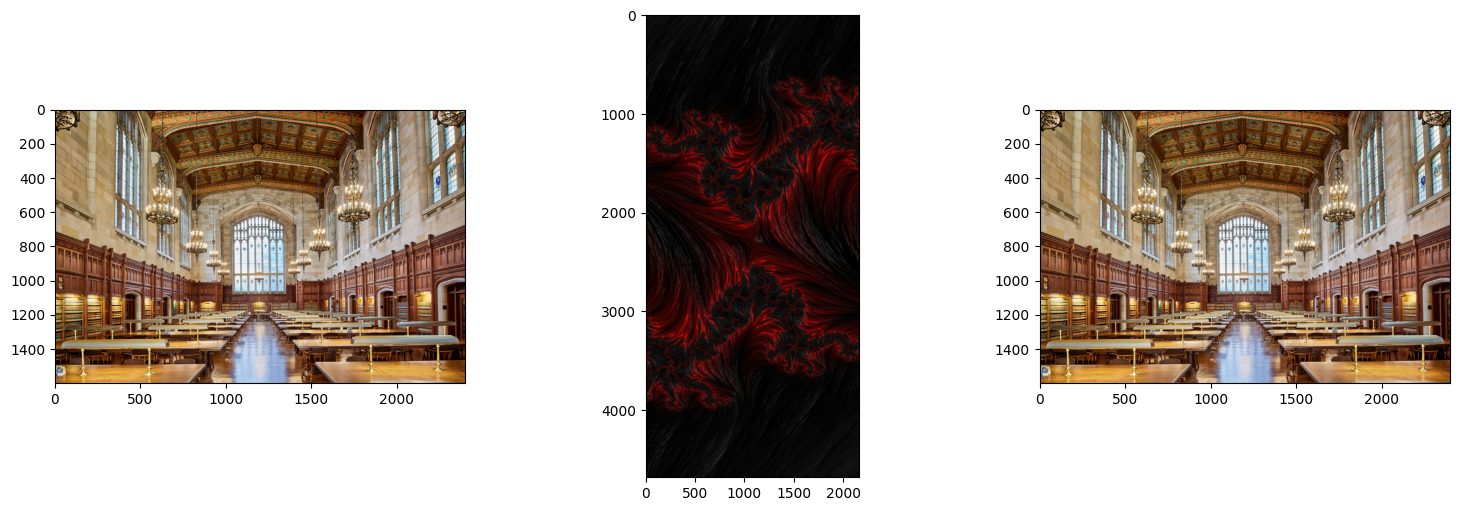

In [574]:
fig , ax = plt.subplots(1,3,figsize=(18,6))

ax[0].imshow(content)
ax[1].imshow(style)
ax[2].imshow(target);

In [575]:
print(content.shape)
print(target.shape)
print(style.shape)

(1600, 2400, 3)
(1600, 2400, 3)
(4680, 2160, 3)


In [576]:
# ImageNet normalisation. Note ToPILImage first, since Resize needs a PIL image
# or tensor rather than a numpy array.
transforms = T.Compose([
    T.ToPILImage(),
    T.Resize(256),
    T.ToTensor(), # Converts to [0,1]
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [577]:
# Only the TARGET has requires_grad=True. Content and style are fixed inputs;
# the target is the parameter being optimised.
# Applying transforms

content = transforms(content).unsqueeze(0).to(device).requires_grad_(False)
target = transforms(target).unsqueeze(0).to(device).requires_grad_(True) # Only target has gradient tape
style = transforms(style).unsqueeze(0).to(device).requires_grad_(False)

In [578]:
print(content.shape)
print(target.shape)
print(style.shape)

torch.Size([1, 3, 256, 384])
torch.Size([1, 3, 256, 384])
torch.Size([1, 3, 554, 256])


In [579]:
content.min(), content.max()

(tensor(-2.1179, device='cuda:0'), tensor(2.5703, device='cuda:0'))

## Defining functions to get gram matrix and feature maps

In [580]:
# Run an image through the network layer by layer and collect the output of every
# convolution.
# Note the loop applies layers one at a time rather than calling net(img) - that
# is the point, since the intermediate activations are what style transfer needs.
# (A forward hook, layer.register_forward_hook, is the general-purpose way to do
# this without stepping through manually.)
def get_feature_map(net, img):

  feature_maps = []
  feature_names = []

  conv_Idx = 0

  for layernum in range(len(net.features)):

    img = net.features[layernum](img)

    if 'Conv2d' in str(net.features[layernum]):

      feature_maps.append(img)
      feature_names.append('ConvLayer_' + str(conv_Idx))
      conv_Idx += 1

  return feature_maps, feature_names

In [581]:
# The GRAM MATRIX - the whole idea of style transfer in one function.
# Flatten each channel to a vector, then compute every pairwise dot product:
# G[i,j] = how much channel i and channel j fire together, summed over all
# positions.
# Because it sums over position, it discards WHERE anything is and keeps only
# which features co-occur. That is a workable definition of 'style': texture,
# colour relationships and brush character, independent of layout.
# The division by (channels*h*w) normalises for image size.
def get_gram_matrix(img):

  _ ,c , h, w = img.shape

  M = img.view(c, h*w)

  gm = torch.mm(M, M.t()) / (c*h*w)

  return gm

In [582]:
# Testing the functions

content_feature_maps, content_feature_names = get_feature_map(alex_net,content)
style_feature_maps, style_feature_names = get_feature_map(alex_net,style)


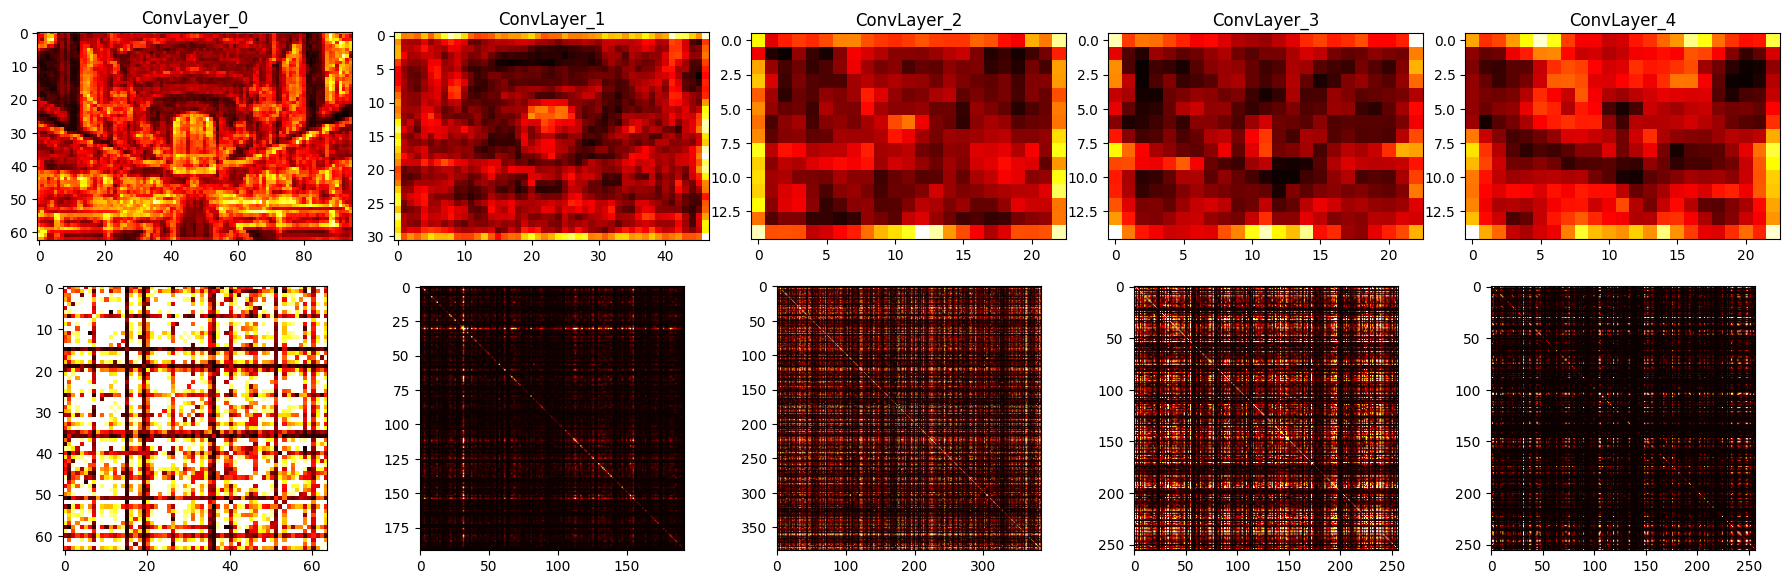

In [583]:
# Content feature maps and their Gram matrices at each of the 5 layers.
fig, ax = plt.subplots(2,5, figsize=(18,6))

for i in range(5):

  pic = np.mean(content_feature_maps[i].cpu().numpy().squeeze(),axis=0)
  pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic)) # Scaling from [0,1]
  ax[0,i].imshow(pic,cmap='hot')
  # ax[0,i].axis('off')
  ax[0,i].set_title(str(content_feature_names[i]))

  pic = get_gram_matrix(content_feature_maps[i]).cpu().numpy()
  pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
  ax[1,i].imshow(pic, cmap='hot',vmax=.1)
  # ax[1,i].axis('off')

plt.tight_layout()



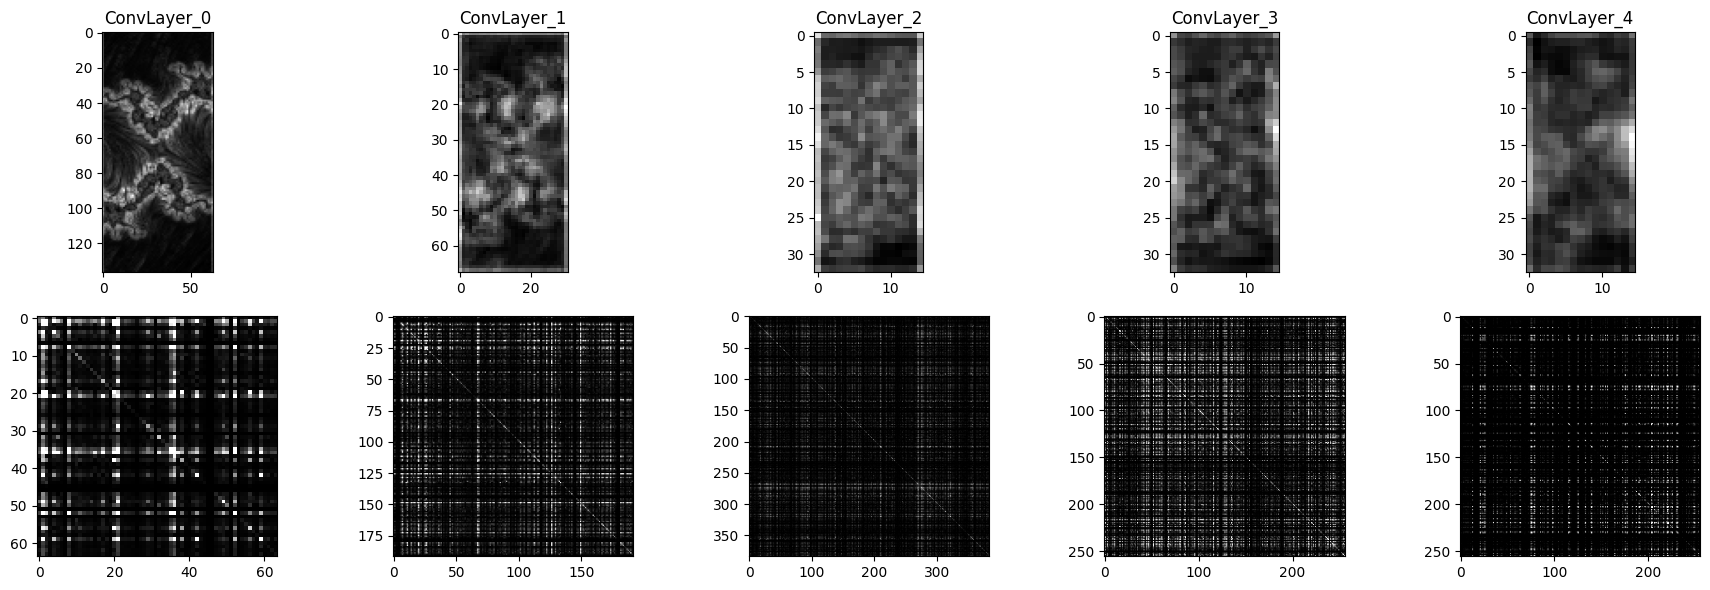

In [584]:
# The same for the style image.
# With only 5 layers there is much less range between fine and coarse features
# than VGG offers - which is exactly why the output will be coarser.
fig, ax = plt.subplots(2,5, figsize=(18,6))

for i in range(5):

  pic = np.mean(style_feature_maps[i].cpu().numpy().squeeze(),axis=0)
  pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic)) # Scaling from [0,1]
  ax[0,i].imshow(pic,cmap='grey')
  # ax[0,i].axis('off')
  ax[0,i].set_title(str(style_feature_names[i]))

  pic = get_gram_matrix(style_feature_maps[i]).cpu().numpy()
  pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
  ax[1,i].imshow(pic, cmap='grey',vmax=.1)
  # ax[1,i].axis('off')

plt.tight_layout()



In [585]:
# Layer choices. Note content comes from ConvLayer_0, the very first layer -
# almost raw edges, which pins the result close to the original pixels.
# The inline comment is right that deeper layers represent content better; try
# ConvLayer_2 or ConvLayer_3 for a more interpretive result.
# Style uses all 5 layers with decreasing weights - early layers (fine texture)
# weighted most.
# Choosing hyperparameters

content_layers = ['ConvLayer_0'] # Deeper layers tend to represent content better
style_layers =  ['ConvLayer_0','ConvLayer_1','ConvLayer_2','ConvLayer_3','ConvLayer_4' ] # Capturing textures at multiple scales
style_weights = [      1       ,      .8      ,     .6      ,    .4      ,      .2      ]


In [586]:
# The optimisation, with the important improvement over the VGG notebook:
# the content and style feature maps are computed ONCE, before the loop, under
# torch.no_grad(). Those images never change, so recomputing them every iteration
# was pure waste - this is roughly a 3x speedup.
#
# style_scaling=2e5 rather than 5e4: AlexNet's Gram matrices are on a different
# scale, so the weight has to be retuned. None of these hyperparameters transfer
# between architectures.
#
# The per-epoch print of content and style loss separately is the right
# diagnostic - it shows which term is dominating.
epochs = 1500
lr = 1e-3 # Increased learning rate substantially
style_scaling = 2e5 # Increased scaling for style loss

optimizer = torch.optim.RMSprop([target], lr=lr)

# Pre-calculate static feature maps
with torch.no_grad():
    content_feature_maps, _ = get_feature_map(alex_net, content)
    style_feature_maps, _ = get_feature_map(alex_net, style)

for epoch in range(epochs):
  target_feature_maps, target_features_names = get_feature_map(alex_net, target)

  style_loss = torch.tensor(0.0, device=device)
  content_loss = torch.tensor(0.0, device=device)

  for i in range(len(target_features_names)):
    name = target_features_names[i]

    if name in content_layers:
      content_loss += torch.mean((target_feature_maps[i] - content_feature_maps[i])**2)

    if name in style_layers:
      t_gm = get_gram_matrix(target_feature_maps[i])
      s_gm = get_gram_matrix(style_feature_maps[i])

      w_idx = style_layers.index(name)
      style_loss += torch.mean((t_gm - s_gm)**2) * style_weights[w_idx]

  loss = content_loss + (style_loss * style_scaling)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f'Epoch {epoch} | Total Loss: {loss.item():.4f} | Content: {content_loss.item():.4f} | Style: {(style_loss * style_scaling).item():.4f}')


Epoch 0 | Total Loss: 34.7355 | Content: 0.0000 | Style: 34.7355
Epoch 100 | Total Loss: 15.7532 | Content: 0.1504 | Style: 15.6028
Epoch 200 | Total Loss: 11.6930 | Content: 0.3003 | Style: 11.3926
Epoch 300 | Total Loss: 9.5074 | Content: 0.4408 | Style: 9.0666
Epoch 400 | Total Loss: 8.1550 | Content: 0.5735 | Style: 7.5815
Epoch 500 | Total Loss: 7.2420 | Content: 0.6971 | Style: 6.5449
Epoch 600 | Total Loss: 6.5814 | Content: 0.8091 | Style: 5.7723
Epoch 700 | Total Loss: 6.0707 | Content: 0.9076 | Style: 5.1631
Epoch 800 | Total Loss: 5.6523 | Content: 0.9911 | Style: 4.6612
Epoch 900 | Total Loss: 5.2937 | Content: 1.0600 | Style: 4.2336
Epoch 1000 | Total Loss: 4.9797 | Content: 1.1151 | Style: 3.8646
Epoch 1100 | Total Loss: 4.6971 | Content: 1.1592 | Style: 3.5379
Epoch 1200 | Total Loss: 4.4399 | Content: 1.1934 | Style: 3.2466
Epoch 1300 | Total Loss: 4.2032 | Content: 1.2199 | Style: 2.9833
Epoch 1400 | Total Loss: 3.9852 | Content: 1.2409 | Style: 2.7443


In [587]:
# Denormalisation for display.
def imshow(img, ax, title=None):
    # Denormalize the image
    inv_normalize = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img = inv_normalize(img)

    # Convert to numpy and transpose for matplotlib
    npimg = img.cpu().detach().numpy().squeeze().transpose((1, 2, 0))

    # Clip values to [0, 1] as imshow expects this range for float images
    npimg = np.clip(npimg, 0, 1)

    ax.imshow(npimg)
    ax.axis('off')
    if title:
        ax.set_title(title)

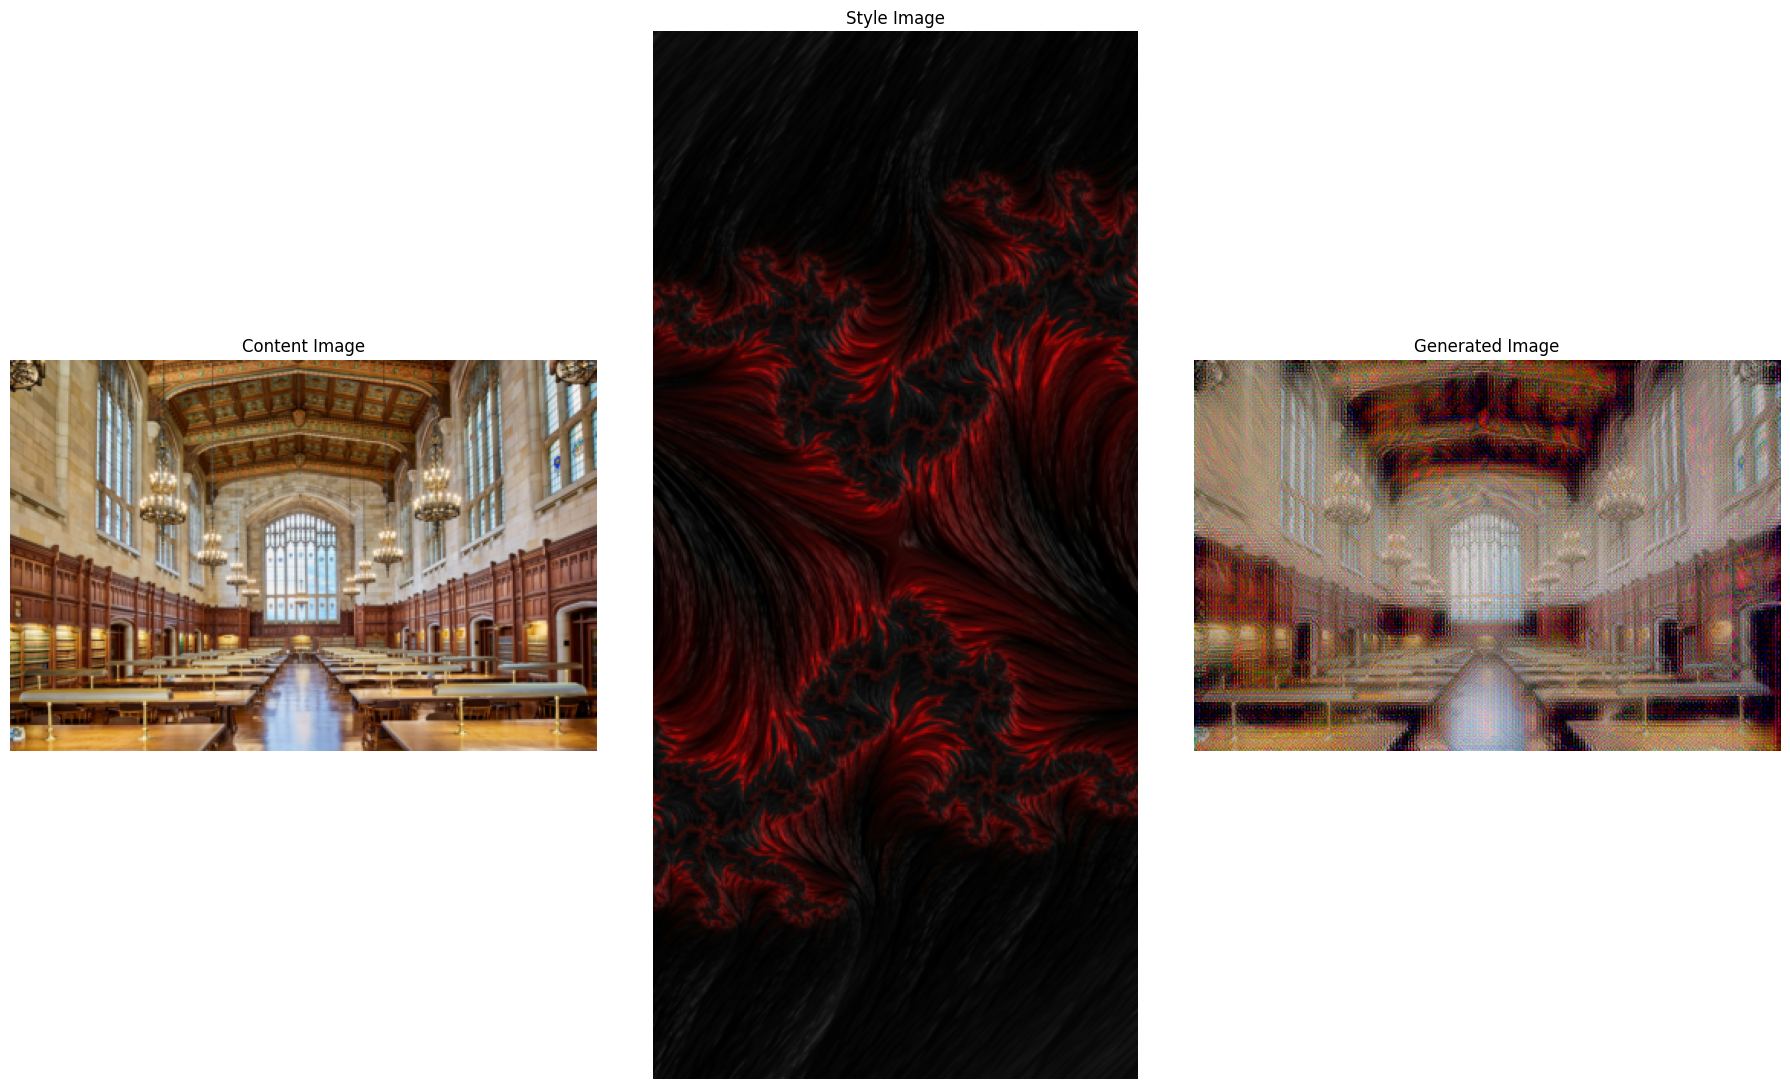

In [588]:
# Content, style and result.
# Compare against the VGG output: AlexNet captures colour and broad texture but
# not fine brushwork. Depth buys a richer vocabulary of visual features - the
# same argument as More on Data/DepthVsBreadth.ipynb, seen here as a visible
# difference rather than a number.
fig, ax = plt.subplots(1,3, figsize=(18,11))

# Plot content image
imshow(content, ax[0], title='Content Image')

# Plot style image
imshow(style, ax[1], title='Style Image')

# Plot target (generated) image
imshow(target, ax[2], title='Generated Image')

plt.tight_layout()
plt.show()